# Analysis of Three Cointegrated Time Series

## Analysis Procedure

The following modules are used in the analysis.

```
from statsmodels.tsa.vector_ar import vecm
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import VECM
```

The steps to perform the analysis are as follows,

1. ADF stationarity test all series and difference series until the test pass. This number of differences will define the integration 
order of the system. VECM models are $I(1)$ so should be stationary after one difference.
2. Estimate model lags using `VAR.select_order`. Verify with ACF-PACF. 
3. After the first two steps it will be known that the series are $I(1)$ and the number of lags will be known. `grangercausalitytests` can be applied to the first differences to determine the common trends and suggest the model rank.
4. Use the Johansen test from `vecm.coint_johansen` to determine the rank of the model, This should be consistent with the Granger causality results.
5. Now estimates for the rank and lag are known and the model parameters can be estimated using `VECM.fit()`. OLS can be used to estimate $\beta$ vectors using time asymptotic form.
6. Verify that residual is stationary using ADF test.


In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot
from pandas import DataFrame, read_csv

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.utils import extract_date_range
from lib.data import ecm, stats, adf, arima, vecm
from lib.plots import comparison, ecm_beta, curve, comparison_stack, stack
from lib.utils import create_ensemble

# Config Plot Style
pyplot.style.use(config.glyfish_style)

In [41]:
def adf_test(xt):
    for i in range(len(xt)):
        result, _ = adf.compute_adf_offset_test(xt[i])
        result.summary()
        if result.status_vals[1]:
            print("Not Stationary")
        else:
            print("Stationary")

def plot_vecm_simulation(t, xt, title):
    labels = [r"$x_1$", r"$x_2$", r"$x_3$"]   
    comparison(xt, t, labels =labels, title=title, xlabel=r"$t$", lw=1, title_offset=0.05)

def pacf_acf_plot(t, dxt, nlags, title):
    acf = [stats.compute_acf(t, samp, nlags=nlags) for samp in dxt] 
    pacf = [arima.compute_pacf(samp, nlags=nlags) for samp in dxt]
    data = [[acf[i][1], pacf[i][1]] for i in range(len(dxt))]
    time = [[acf[i][0], pacf[i][0]] for i in range(len(dxt))]
    comparison_stack(data, time, title=title, xlabel=r"Lag", ylim=(-0.25, 1.0), figsize=(10, 8), 
                     labels=[["ACF", "PACF"]], ylabels=[r"$\Delta EWA$", r"$\Delta IGE$", r"$\Delta EWC$"])

## Analyzed Price Series

In [3]:
file_path = os.path.abspath('../../../data/algorithmic_trading/EWA.csv')
ewa_data = read_csv(file_path, index_col=0, parse_dates=True).sort_values(by='Date').dropna()
ewa_data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1996-03-18,10.125,10.125,10.000,10.000,3.283057,35200
1996-03-19,10.125,10.125,10.125,10.125,3.324095,500
1996-03-20,10.125,10.125,10.125,10.125,3.324095,500
1996-03-21,10.250,10.250,10.250,10.250,3.365134,37700
1996-03-22,10.250,10.250,10.250,10.250,3.365134,600


In [4]:
file_path = os.path.abspath('../../../data/algorithmic_trading/EWC.csv')
ewc_data = read_csv(file_path, index_col=0, parse_dates=True).sort_values(by='Date').dropna()
ewc_data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1996-03-18,10.3125,10.3125,10.3125,10.3125,4.601596,500
1996-03-19,10.3750,10.3750,10.3750,10.3750,4.629483,200
1996-03-20,10.3750,10.3750,10.3750,10.3750,4.629483,0
1996-03-21,10.3750,10.3750,10.3750,10.3750,4.629483,0
1996-03-22,10.3750,10.3750,10.3750,10.3750,4.629483,0


In [6]:
file_path = os.path.abspath('../../../data/algorithmic_trading/EWC.csv')
ewc_data = read_csv(file_path, index_col=0, parse_dates=True).sort_values(by='Date').dropna()
ewc_data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1996-03-18,10.3125,10.3125,10.3125,10.3125,4.601596,500
1996-03-19,10.3750,10.3750,10.3750,10.3750,4.629483,200
1996-03-20,10.3750,10.3750,10.3750,10.3750,4.629483,0
1996-03-21,10.3750,10.3750,10.3750,10.3750,4.629483,0
1996-03-22,10.3750,10.3750,10.3750,10.3750,4.629483,0


In [7]:
file_path = os.path.abspath('../../../data/algorithmic_trading/IGE.csv')
ige_data = read_csv(file_path, index_col=0, parse_dates=True).sort_values(by='Date').dropna()
ige_data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2001-11-26,15.168333,15.168333,15.168333,15.168333,9.653491,0
2001-11-27,15.168333,15.168333,15.168333,15.168333,9.653491,0
2001-11-28,15.168333,15.168333,15.168333,15.168333,9.653491,0
2001-11-29,15.168333,15.168333,15.168333,15.168333,9.653491,0
2001-11-30,15.220000,15.220000,15.220000,15.220000,9.686371,600


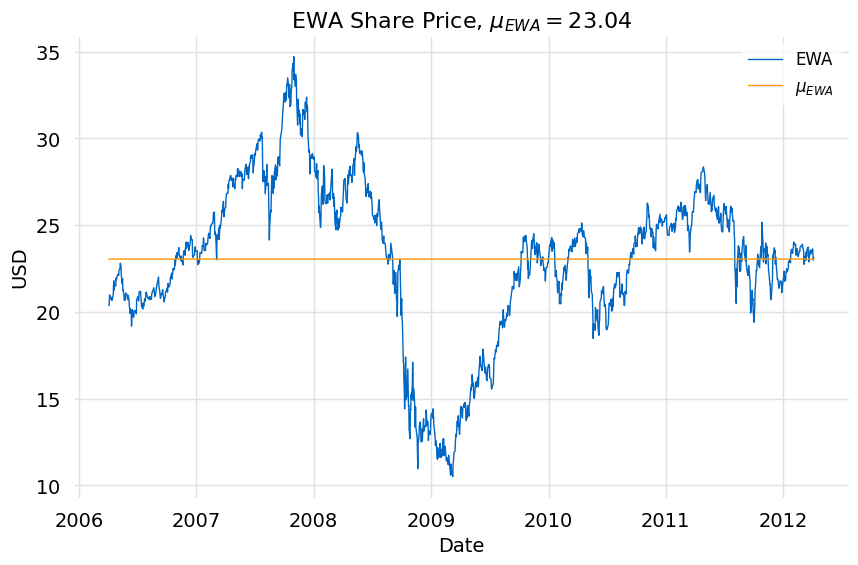

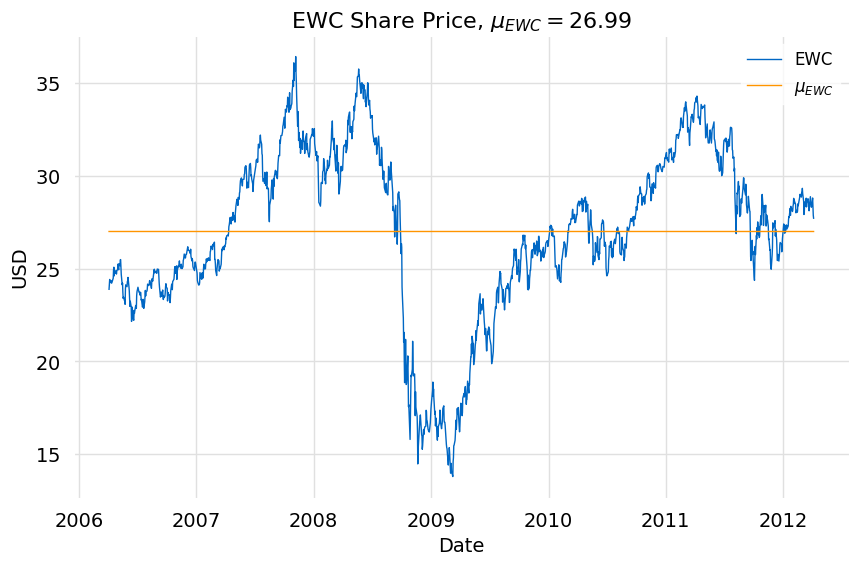

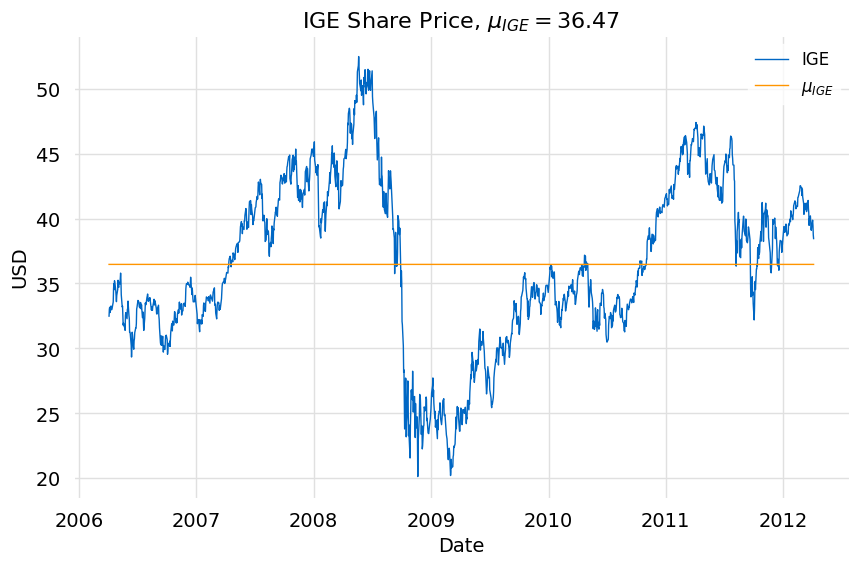

In [8]:
ewa_date, ewa_close = extract_date_range(ewa_data.index.to_numpy(), ewa_data['Close'].to_numpy(), '2006-04-04', '2012-04-09')
ewc_date, ewc_close = extract_date_range(ewc_data.index.to_numpy(), ewc_data['Close'].to_numpy(), '2006-04-04', '2012-04-09')
ige_date, ige_close = extract_date_range(ige_data.index.to_numpy(), ige_data['Close'].to_numpy(), '2006-04-04', '2012-04-09')

ewa_close_mean = numpy.full(ewa_close.shape, numpy.mean(ewa_close))
ewc_close_mean = numpy.full(ewc_close.shape, numpy.mean(ewc_close))
ige_close_mean = numpy.full(ige_close.shape, numpy.mean(ige_close))

title = f"EWA Share Price, $\mu_{{EWA}} = {numpy.mean(ewa_close):.2f}$"
comparison([ewa_close, ewa_close_mean], [ewa_date, ewa_date], labels=['EWA', r"$\mu_{EWA}$"], title=title, xlabel='Date', ylabel='USD', lw=1)

title = f"EWC Share Price, $\mu_{{EWC}} = {numpy.mean(ewc_close):.2f}$"
comparison([ewc_close, ewc_close_mean], [ewc_date, ewc_date], labels=['EWC', r"$\mu_{EWC}$"], title=title, xlabel='Date', ylabel='USD', lw=1)

title = f"IGE Share Price, $\mu_{{IGE}} = {numpy.mean(ige_close):.2f}$"
comparison([ige_close, ige_close_mean], [ewc_date, ewc_date], labels=['IGE', r"$\mu_{IGE}$"], title=title, xlabel='Date', ylabel='USD', lw=1)

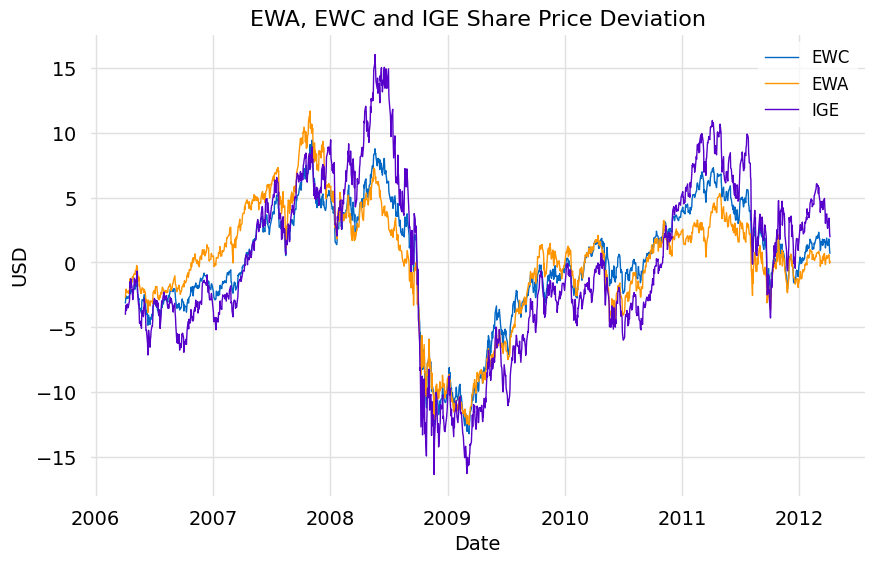

In [9]:
title = 'EWA, EWC and IGE Share Price Deviation'
ewc_close_dev = ewc_close - numpy.mean(ewc_close)
ewa_close_dev = ewa_close - numpy.mean(ewa_close)
ige_close_dev = ige_close - numpy.mean(ige_close)
comparison([ewc_close_dev, ewa_close_dev, ige_close_dev], [ewc_date, ewa_date, ige_date], labels=['EWC', 'EWA', 'IGE'], title=title, xlabel='Date', ylabel='USD', lw=1)

### Stationarity Test

All series are just barely stationary so are close to browninag motion. The first difference is stationary.

In [26]:
adf_test([ewc_close, ewa_close, ige_close])

╒════════════════╤═════════════╕
│ Test Statistic │   -1.98767  │
├────────────────┼─────────────┤
│ pvalue         │    0.292006 │
├────────────────┼─────────────┤
│ Lags           │    0        │
├────────────────┼─────────────┤
│ Number Obs     │ 1513        │
╘════════════════╧═════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -3.43468 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -2.86345 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -2.56779 │ Passed   │
╘════════════════╧══════════════════╧══════════╛
Not Stationary
╒════════════════╤═════════════╕
│ Test Statistic │   -1.89515  │
├────────────────┼─────────────┤
│ pvalue         │    0.334347 │
├────────────────┼─────────────┤
│ Lags           │    1        │
├────────────────┼─────────────┤
│ Number Obs    

In [36]:
dt, dxt = stats.compute_diff(ewa_date, numpy.array([ewa_close, ige_close, ewc_close]))
adf_test(dxt)

╒════════════════╤═══════════╕
│ Test Statistic │  -43.6018 │
├────────────────┼───────────┤
│ pvalue         │    0      │
├────────────────┼───────────┤
│ Lags           │    0      │
├────────────────┼───────────┤
│ Number Obs     │ 1512      │
╘════════════════╧═══════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -3.43468 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -2.86345 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -2.56779 │ Failed   │
╘════════════════╧══════════════════╧══════════╛
Stationary
╒════════════════╤═══════════╕
│ Test Statistic │  -29.1233 │
├────────────────┼───────────┤
│ pvalue         │    0      │
├────────────────┼───────────┤
│ Lags           │    1      │
├────────────────┼───────────┤
│ Number Obs     │ 1511      │
╘════════════════╧═══

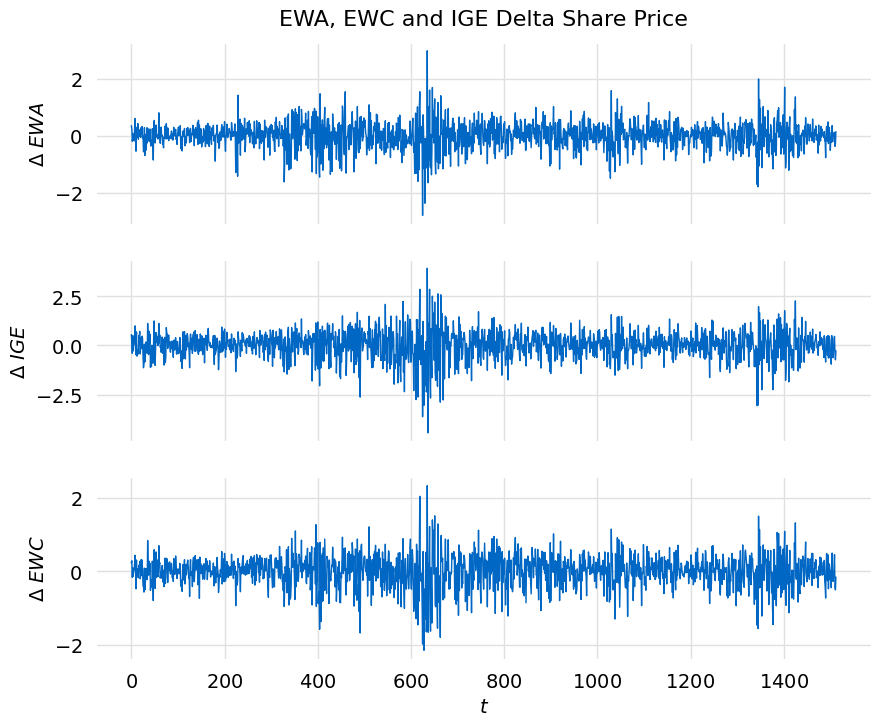

In [37]:
title = 'EWA, EWC and IGE Delta Share Price'
labels = [r"$\Delta\ EWA$", r"$\Delta\ IGE$", r"$\Delta\ EWC$"]   
stack(dxt, title=title, ylabels=labels, xlabel=r"$t$", lw=1, title_offset=0.05, figsize=(10, 8))

### Order Determination

All series are close to havong order 1.

In [38]:
result, result_model = vecm.compute_order(numpy.array([ewa_close, ige_close, ewc_close]), maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,-6.261,-6.208,0.001909,-6.241
1,-6.318,-6.233*,0.001804,-6.286*
2,-6.327*,-6.211,0.001787*,-6.284
3,-6.327,-6.179,0.001787,-6.272
4,-6.324,-6.144,0.001792,-6.257


In [39]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "38fe1741-5877-4144-b964-e89124249c74",
   "_VAROrderTestReport__order": {
      "test_id": "38fe1741-5877-4144-b964-e89124249c74",
      "label": "$\\tau_{min}$",
      "value": 1
   },
   "_VAROrderTestReport__aic": {
      "test_id": "38fe1741-5877-4144-b964-e89124249c74",
      "order": {
         "test_id": "38fe1741-5877-4144-b964-e89124249c74",
         "label": "$\\tau_{AIC}$",
         "value": 2
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "38fe1741-5877-4144-b964-e89124249c74",
         "label": "$\\varepsilon_{AIC}$",
         "value": -6.327368024360867
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "38fe1741-5877-4144-b964-e89124249c74",
      "order": {
         "test_id": "38fe1741-5877-4144-b964-e89124249c74",
         "label": "$\\tau_{BIC}$",
         "value": 1
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "38fe1741-5877-4144-b964-e89124249c74",
         

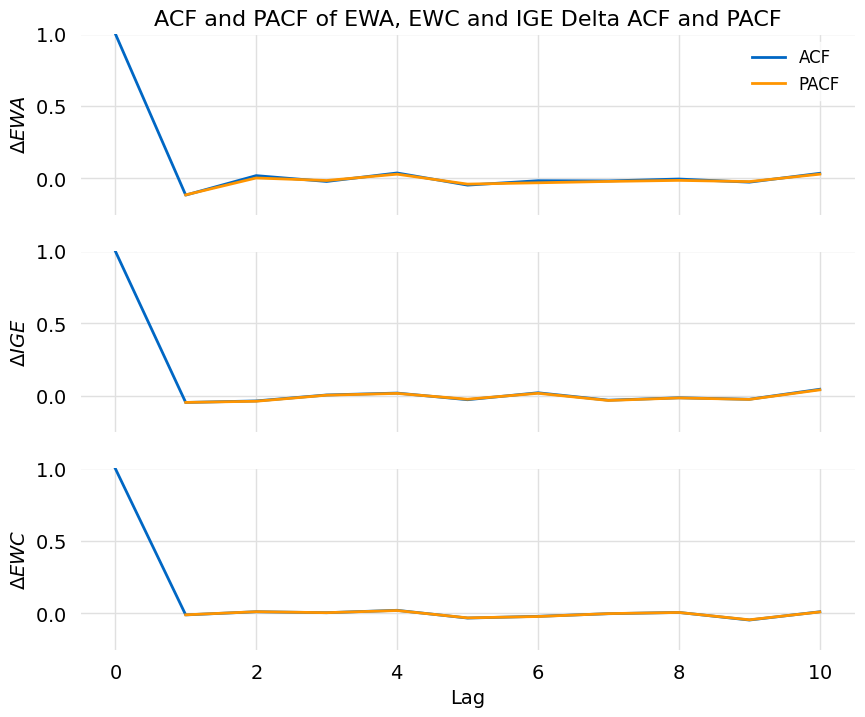

In [42]:
nlags = 10
title = f"ACF and PACF of EWA, EWC and IGE Delta ACF and PACF"
pacf_acf_plot(numpy.arange(0, len(dxt[0])), dxt, 10, title)

### Granger Causality

The Granger causalty analysis is the same as for the EWA-EWC analysis. If two lags are assumed EWA is causal to EWC and close to casing IGE.

In [43]:
result, result_model = stats.compute_causality_matrix(dxt, nlags=2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=1509, df_num=1
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=1
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=1
parameter F test:         F=20.0580 , p=0.0000  , df_denom=1509, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=1508, df_num=2
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=2
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=2
parameter F test:         F=10.1065 , p=0.0000  , df_denom=1508, df_num=2

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1490  , p=0.6995  , df_denom=1509, df_num=1
ssr based chi2 test:   chi2=0.1493  , p=0.6992  , df=1
likelihood ratio test: chi2=0.1493  , p=0.6992  , df=1
parameter F test:         F=0.1490  , p=0.6995  , df_denom=1509, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.3068  , p=0.

In [44]:
result.head(10)

,pvalue,critical_value,result,dependent_var,causal_var
1,1.0000,0.05,False,1,1
2,0.6995,0.05,False,1,2
3,0.0057,0.05,True,1,3
4,0.6239,0.05,False,2,1
5,1.0000,0.05,False,2,2
6,0.2530,0.05,False,2,3
7,0.7229,0.05,False,3,1
8,0.5129,0.05,False,3,2
9,1.0000,0.05,False,3,3


In [18]:
print(result_model.to_json(pretty=True))

{
   "test_id": "8968a8b9-b438-4c67-a32d-b93500edce46",
   "rank": 1,
   "results": [
      {
         "_GrangerCausalityTestResult__est_id": "8968a8b9-b438-4c67-a32d-b93500edce46",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 1,
         "_GrangerCausalityTestResult__pvalue": 1.0,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "8968a8b9-b438-4c67-a32d-b93500edce46",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 2,
         "_GrangerCausalityTestResult__pvalue": 0.7229,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "8968a8b9-b438-4c67-a32d-b93500edce46",
         "_GrangerCausalityTestResult__de

### Johansen Test for Cointegration

In [46]:
result, result_model, _ = vecm.compute_johansen_coint_test(numpy.array([ewa_close, ige_close, ewc_close]), 1)

In [47]:
result.summary()

Trace Statistic
╒═══════════════════╤══════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│ Null Hypothesis   │   Test Statistic │   Critical Value 90% │   Critical Value 95% │   Critical Value 99% │
╞═══════════════════╪══════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ r <= 0            │           28.242 │               27.067 │               29.796 │               35.463 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 1            │           14.036 │               13.429 │               15.494 │               19.935 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 2            │            4.577 │                2.705 │                3.841 │                6.635 │
╘═══════════════════╧══════════════════╧══════════════════════╧══════════════════════╧══════════════════

In [21]:
print(result_model.to_json(pretty=True))

{
   "test_id": "38981ff2-0afe-44d7-bf16-248268af3589",
   "trace_test": [
      {
         "test_id": "38981ff2-0afe-44d7-bf16-248268af3589",
         "test_rank": 0,
         "null_hypothesis": "r<=0",
         "test_stat": 28.241769454593534,
         "critical_values": [
            27.0669,
            29.7961,
            35.4628
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 99%"
         ],
         "test_result": [
            true,
            false,
            false
         ]
      },
      {
         "test_id": "38981ff2-0afe-44d7-bf16-248268af3589",
         "test_rank": 1,
         "null_hypothesis": "r<=1",
         "test_stat": 14.035632195923275,
         "critical_values": [
            13.4294,
            15.4943,
            19.9349
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Val

### VECM Parameter Estimation

In [48]:
result, result_model = vecm.compute_estimate(numpy.array([ewa_close, ige_close, ewc_close]), maxlags=1, rank=2)
result.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
const,0.0294,0.030,0.968,0.333,-0.030,0.089
L1.y1,-0.1618,0.042,-3.833,0.000,-0.245,-0.079
L1.y2,-0.0926,0.038,-2.424,0.015,-0.167,-0.018
L1.y3,0.2083,0.067,3.105,0.002,0.077,0.340
,coef,std err,z,P>|z|,[0.025,0.975]
const,0.1152,0.047,2.474,0.013,0.024,0.206
L1.y1,-0.0018,0.065,-0.028,0.978,-0.129,0.125
L1.y2,-0.0739,0.059,-1.263,0.206,-0.189,0.041
L1.y3,0.0576,0.103,0.561,0.575,-0.144,0.259
,coef,std err,z,P>|z|,[0.025,0.975]


In [49]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VECM",
   "rank": 2,
   "const": [
      {
         "est": 0.029414280902089262,
         "err": 0.030382544476460757,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "ca96168f-7eb6-485f-aa20-4276ea6aa714",
         "param_type": "VECM_CONST"
      },
      {
         "est": 0.11516190969403423,
         "err": 0.04655160990622478,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "ca96168f-7eb6-485f-aa20-4276ea6aa714",
         "param_type": "VECM_CONST"
      },
      {
         "est": 0.06333836089409339,
         "err": 0.028514690598421467,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 2,
         "column": 0,
         "order": 0,
         "est_id": "ca96168f-7eb6-485f-aa20-4276ea6aa714",
         "param_typ